In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpl_patches
import math
import os
import datetime
import time
import csv
import statistics
import scipy.special
import scipy.stats as st
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats
from scipy import signal
pd.set_option('display.max_columns', 500)

In [2]:
# designate preferred font for plots
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.family'] = "sans-serif"

In [20]:
# set to the directory containing the folder of LICOR files
os.chdir('C:\\Users\\hanna\\code\\gas_scouter')

# assemble a list of the files to use when appending data frames
directory = '20230810'
files_list = []
for filename in os.listdir(directory):
    f = os.path.join(directory, filename)
    if os.path.isfile(f):
        files_list.append(filename)
files_list = [item for item in files_list if (item.endswith('.data') or item.endswith('.txt'))]
# check that the list matches what you expect
files_list

['TG10-01095-2023-08-10T060000.data.txt']

In [21]:
# reset the directory inside the folder of files so that concat will work
os.chdir(directory)

# compile all files into a single data frame 
data_comp = pd.DataFrame()
for filename in files_list:
    data = pd.read_table(filename, skiprows = [0,1,2,3,4,6], sep='\s+')
    data = pd.DataFrame(data)
    data_comp = pd.concat([data_comp, data])

# drop unnecessary columns
drop_list = ['DATAH',
             'NDX',
             'DIAG',
             'REMARK',
             'DATE']

# data_comp = data_comp.drop(columns=drop_list)

In [22]:
# convert times to pdt/pst
times = []
for epoch_time in data_comp['SECONDS']:
    pdt_time = datetime.datetime.fromtimestamp(epoch_time) 
    #pdt_time = time.localtime(epoch_time)
    times.append(pdt_time)

data_comp['Time'] = times

# confirm the time zone looks correct
data_comp.head()

,DATAH,SECONDS,NANOSECONDS,NDX,DIAG,REMARK,DATE,TIME,H2O,CO2,CH4,CAVITY_P,CAVITY_T,LASER_PHASE_P,LASER_T,RESIDUAL,RING_DOWN_TIME,THERMAL_ENCLOSURE_T,PHASE_ERROR,LASER_T_SHIFT,INPUT_VOLTAGE,CHK,Time
0,DATA,1691672863,225457906,28,256,NaN,2023-08-10,06:07:43,NaN,NaN,NaN,96.4249,24.7539,96.1942,28.0827,0.0,0.0,31.6195,-16000.0,0.0,16.1784,138,2023-08-10 06:07:43
1,DATA,1691672864,225404977,32,256,NaN,2023-08-10,06:07:44,NaN,NaN,NaN,96.3840,24.7546,96.1550,39.1339,0.0,0.0,31.6203,-16000.0,0.0,16.1545,14,2023-08-10 06:07:44
2,DATA,1691672865,225364923,36,256,NaN,2023-08-10,06:07:45,NaN,NaN,NaN,96.3689,24.7546,96.1419,40.9861,0.0,0.0,31.6210,-16000.0,0.0,16.1769,85,2023-08-10 06:07:45
3,DATA,1691672866,225347995,40,256,NaN,2023-08-10,06:07:46,NaN,NaN,NaN,96.3616,24.7546,96.1358,41.2433,0.0,0.0,31.6197,-16000.0,0.0,16.1831,125,2023-08-10 06:07:46
4,DATA,1691672867,225315093,44,256,NaN,2023-08-10,06:07:47,NaN,NaN,NaN,96.3579,24.7546,96.1317,41.2938,0.0,0.0,31.6208,-16000.0,0.0,16.1831,121,2023-08-10 06:07:47


In [23]:
# assign indices by time, replacing overlapping indices from original files
data_filt = data_comp
data_filt.set_index('Time', inplace=True, drop=True)
data_filt.reset_index(inplace=True)

Text(0, 0.5, 'pCH4 (ppm)')

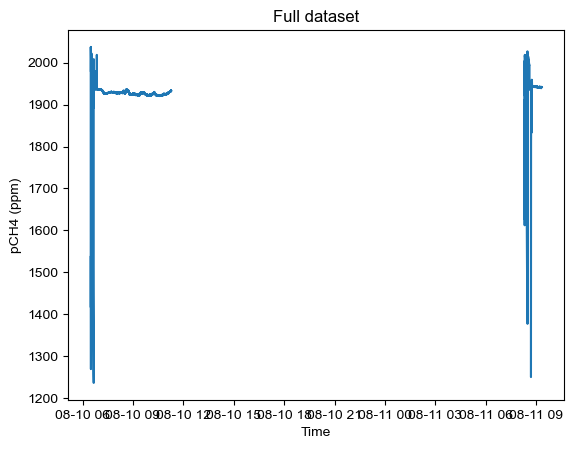

In [24]:
# check how the dataset is looking!
x = data_filt.Time
y = data_filt.CH4
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_title('Full dataset')
ax.set_xlabel('Time')
ax.set_ylabel('pCH4 (ppm)')

Text(0, 0.5, 'pCH4 (ppm)')

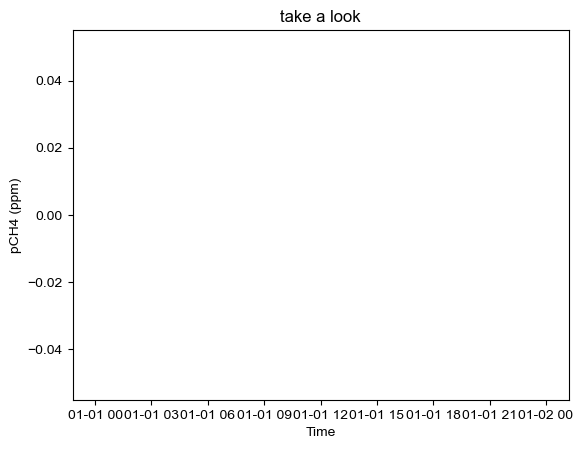

In [25]:
# if needed, designate a specific stretch of time to take a look at
my_start = '15:03 2023_08_15'
my_end = '15:20 2023_08_15'

my_start = datetime.datetime.strptime(my_start, "%H:%M %Y_%m_%d")
my_end = datetime.datetime.strptime(my_end, "%H:%M %Y_%m_%d")

my_stindex = data_filt.Time.searchsorted(my_start)
my_endindex = data_filt.Time.searchsorted(my_end)
[my_stindex, my_endindex]

# plot it up
x = data_filt.Time[my_stindex:my_endindex]
y = data_filt.CH4[my_stindex:my_endindex]
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_title('take a look')
ax.set_xlabel('Time')
ax.set_ylabel('pCH4 (ppm)')

In [26]:
print("Input the date of flux measurements (yyyy_mm_dd).")
flux_date = input()

Input the date of flux measurements (yyyy_mm_dd).


 2023_08_10


In [51]:
# input measurement names, start times, and temperatures

flux_info = pd.read_csv('flux_info.tsv', sep='\t')

In [28]:
# convert to datetimes that time module can parse
flux_times = [time + " " + flux_date for time in flux_info.flux_time]
flux_datetimes = [datetime.datetime.strptime(item, "%H:%M:%S %Y_%m_%d") for item in flux_times]
flux_times

['7:00:04 2023_08_10',
 '7:03:04 2023_08_10',
 '7:06:05 2023_08_10',
 '7:09:06 2023_08_10',
 '7:12:07 2023_08_10',
 '7:19:21 2023_08_10',
 '7:22:23 2023_08_10',
 '7:25:23 2023_08_10',
 '7:28:24 2023_08_10',
 '7:31:26 2023_08_10',
 '7:58:46 2023_08_10',
 '8:01:47 2023_08_10',
 '8:04:48 2023_08_10',
 '8:07:50 2023_08_10',
 '8:10:50 2023_08_10',
 '8:20:49 2023_08_10',
 '8:23:50 2023_08_10',
 '8:26:51 2023_08_10',
 '8:29:52 2023_08_10',
 '8:32:54 2023_08_10',
 '9:22:16 2023_08_10',
 '9:25:16 2023_08_10',
 '9:28:17 2023_08_10',
 '9:31:17 2023_08_10',
 '9:34:18 2023_08_10',
 '9:41:29 2023_08_10',
 '9:44:30 2023_08_10',
 '9:47:30 2023_08_10',
 '9:50:31 2023_08_10',
 '9:53:32 2023_08_10',
 '10:01:14 2023_08_10',
 '10:04:15 2023_08_10',
 '10:07:16 2023_08_10',
 '10:10:16 2023_08_10',
 '10:13:17 2023_08_10',
 '10:34:02 2023_08_10',
 '10:37:03 2023_08_10',
 '10:40:03 2023_08_10',
 '10:43:04 2023_08_10',
 '10:46:05 2023_08_10',
 '10:53:22 2023_08_10',
 '10:56:23 2023_08_10',
 '10:59:25 2023_08_10'

In [29]:
# compute start and end times where data will be collected
# for a 10 min field measurement, begin 1 min after the measurement nominally began and take the next 8 mins
start_time = datetime.timedelta(minutes=-0.4167)
end_time = datetime.timedelta(minutes=1.5833)
flux_start = [time + start_time for time in flux_datetimes]
flux_end = [time + end_time for time in flux_datetimes]

# find the indices in data_filt between which each flux measurement occurs
start_index = []
for item in flux_start:
    ind = data_filt.Time.searchsorted(item)
    start_index.append(ind)
end_index = []
for item in flux_end:
    ind = data_filt.Time.searchsorted(item)
    end_index.append(ind)
# [start_index, end_index]
data_filt.head()

,Time,DATAH,SECONDS,NANOSECONDS,NDX,DIAG,REMARK,DATE,TIME,H2O,CO2,CH4,CAVITY_P,CAVITY_T,LASER_PHASE_P,LASER_T,RESIDUAL,RING_DOWN_TIME,THERMAL_ENCLOSURE_T,PHASE_ERROR,LASER_T_SHIFT,INPUT_VOLTAGE,CHK
0,2023-08-10 06:07:43,DATA,1691672863,225457906,28,256,NaN,2023-08-10,06:07:43,NaN,NaN,NaN,96.4249,24.7539,96.1942,28.0827,0.0,0.0,31.6195,-16000.0,0.0,16.1784,138
1,2023-08-10 06:07:44,DATA,1691672864,225404977,32,256,NaN,2023-08-10,06:07:44,NaN,NaN,NaN,96.3840,24.7546,96.1550,39.1339,0.0,0.0,31.6203,-16000.0,0.0,16.1545,14
2,2023-08-10 06:07:45,DATA,1691672865,225364923,36,256,NaN,2023-08-10,06:07:45,NaN,NaN,NaN,96.3689,24.7546,96.1419,40.9861,0.0,0.0,31.6210,-16000.0,0.0,16.1769,85
3,2023-08-10 06:07:46,DATA,1691672866,225347995,40,256,NaN,2023-08-10,06:07:46,NaN,NaN,NaN,96.3616,24.7546,96.1358,41.2433,0.0,0.0,31.6197,-16000.0,0.0,16.1831,125
4,2023-08-10 06:07:47,DATA,1691672867,225315093,44,256,NaN,2023-08-10,06:07:47,NaN,NaN,NaN,96.3579,24.7546,96.1317,41.2938,0.0,0.0,31.6208,-16000.0,0.0,16.1831,121


In [30]:
# calculate CH4_dry

def calc_dry(ch4,h2o):
    dry = ch4 * (1 / (1 - (h2o / 1e6)))
    return dry

data_filt['CH4_dry'] = data_filt.apply(lambda x: calc_dry(x.CH4, x.H2O), axis = 1)

# confirm the values look correct
data_filt.tail()

,Time,DATAH,SECONDS,NANOSECONDS,NDX,DIAG,REMARK,DATE,TIME,H2O,CO2,CH4,CAVITY_P,CAVITY_T,LASER_PHASE_P,LASER_T,RESIDUAL,RING_DOWN_TIME,THERMAL_ENCLOSURE_T,PHASE_ERROR,LASER_T_SHIFT,INPUT_VOLTAGE,CHK,CH4_dry
23568,2023-08-11 09:19:56,DATA,1691770796,91872930,20123,0,NaN,2023-08-11,09:19:56,15555.054,427.16522,1941.6039,40.1333,54.7117,33.4488,41.5797,0.002892,14.5070,54.5205,-68.25,0.319479,15.6076,251,1972.282866
23569,2023-08-11 09:19:57,DATA,1691770797,91872930,20127,0,NaN,2023-08-11,09:19:57,15559.743,426.87915,1941.5381,40.1325,54.7117,33.4492,41.5797,0.002889,14.5067,54.5207,-115.75,0.319479,15.6064,231,1972.225421
23570,2023-08-11 09:19:58,DATA,1691770798,91872930,20131,0,NaN,2023-08-11,09:19:58,15578.230,427.02606,1941.5503,40.1317,54.7117,33.4480,41.5797,0.002904,14.5063,54.5207,-27.00,0.319479,15.6076,140,1972.274851
23571,2023-08-11 09:19:59,DATA,1691770799,91872930,20135,0,NaN,2023-08-11,09:19:59,15587.503,427.08356,1941.6370,40.1329,54.7117,33.4484,41.5797,0.002902,14.5059,54.5204,-137.25,0.319479,15.6080,108,1972.381503
23572,2023-08-11 09:20:00,DATA,1691770800,91872930,20139,0,NaN,2023-08-11,09:20:00,15588.235,426.64676,1941.6011,40.1321,54.7117,33.4492,41.5797,0.002909,14.5058,54.5209,-203.00,0.319479,15.6076,21,1972.346501


In [31]:
# initialize a dictionary of data frames for each flux
flux_dfs = {}
for item in flux_info.flux_name:
    flux_dfs[item] = pd.DataFrame()
    
# assemble the dictionary!
for count, key in enumerate(flux_dfs):
    flux_dfs[key] = data_filt.loc[
                                start_index[count]:end_index[count],
                                ['Time','CH4_dry']
                                ]

# reindex each dataframe in the dictionary
for key in flux_dfs:
    flux_dfs[key].reset_index(inplace=True, drop=True)
    
# for each flux, add a column for time elapsed during measurement
# time elapsed is calculated as a timedelta; convert to float in minutes

for key in flux_dfs:
    elapsed = []
    for ind, _ in enumerate(flux_dfs[key].Time):
        diff = flux_dfs[key].Time[ind] - flux_dfs[key].Time[0]
        diff = datetime.timedelta.total_seconds(diff)
        diff = diff/60
        diff = float(diff)
        elapsed.append(diff)
    flux_dfs[key]['Elapsed'] = elapsed

In [32]:
%matplotlib inline

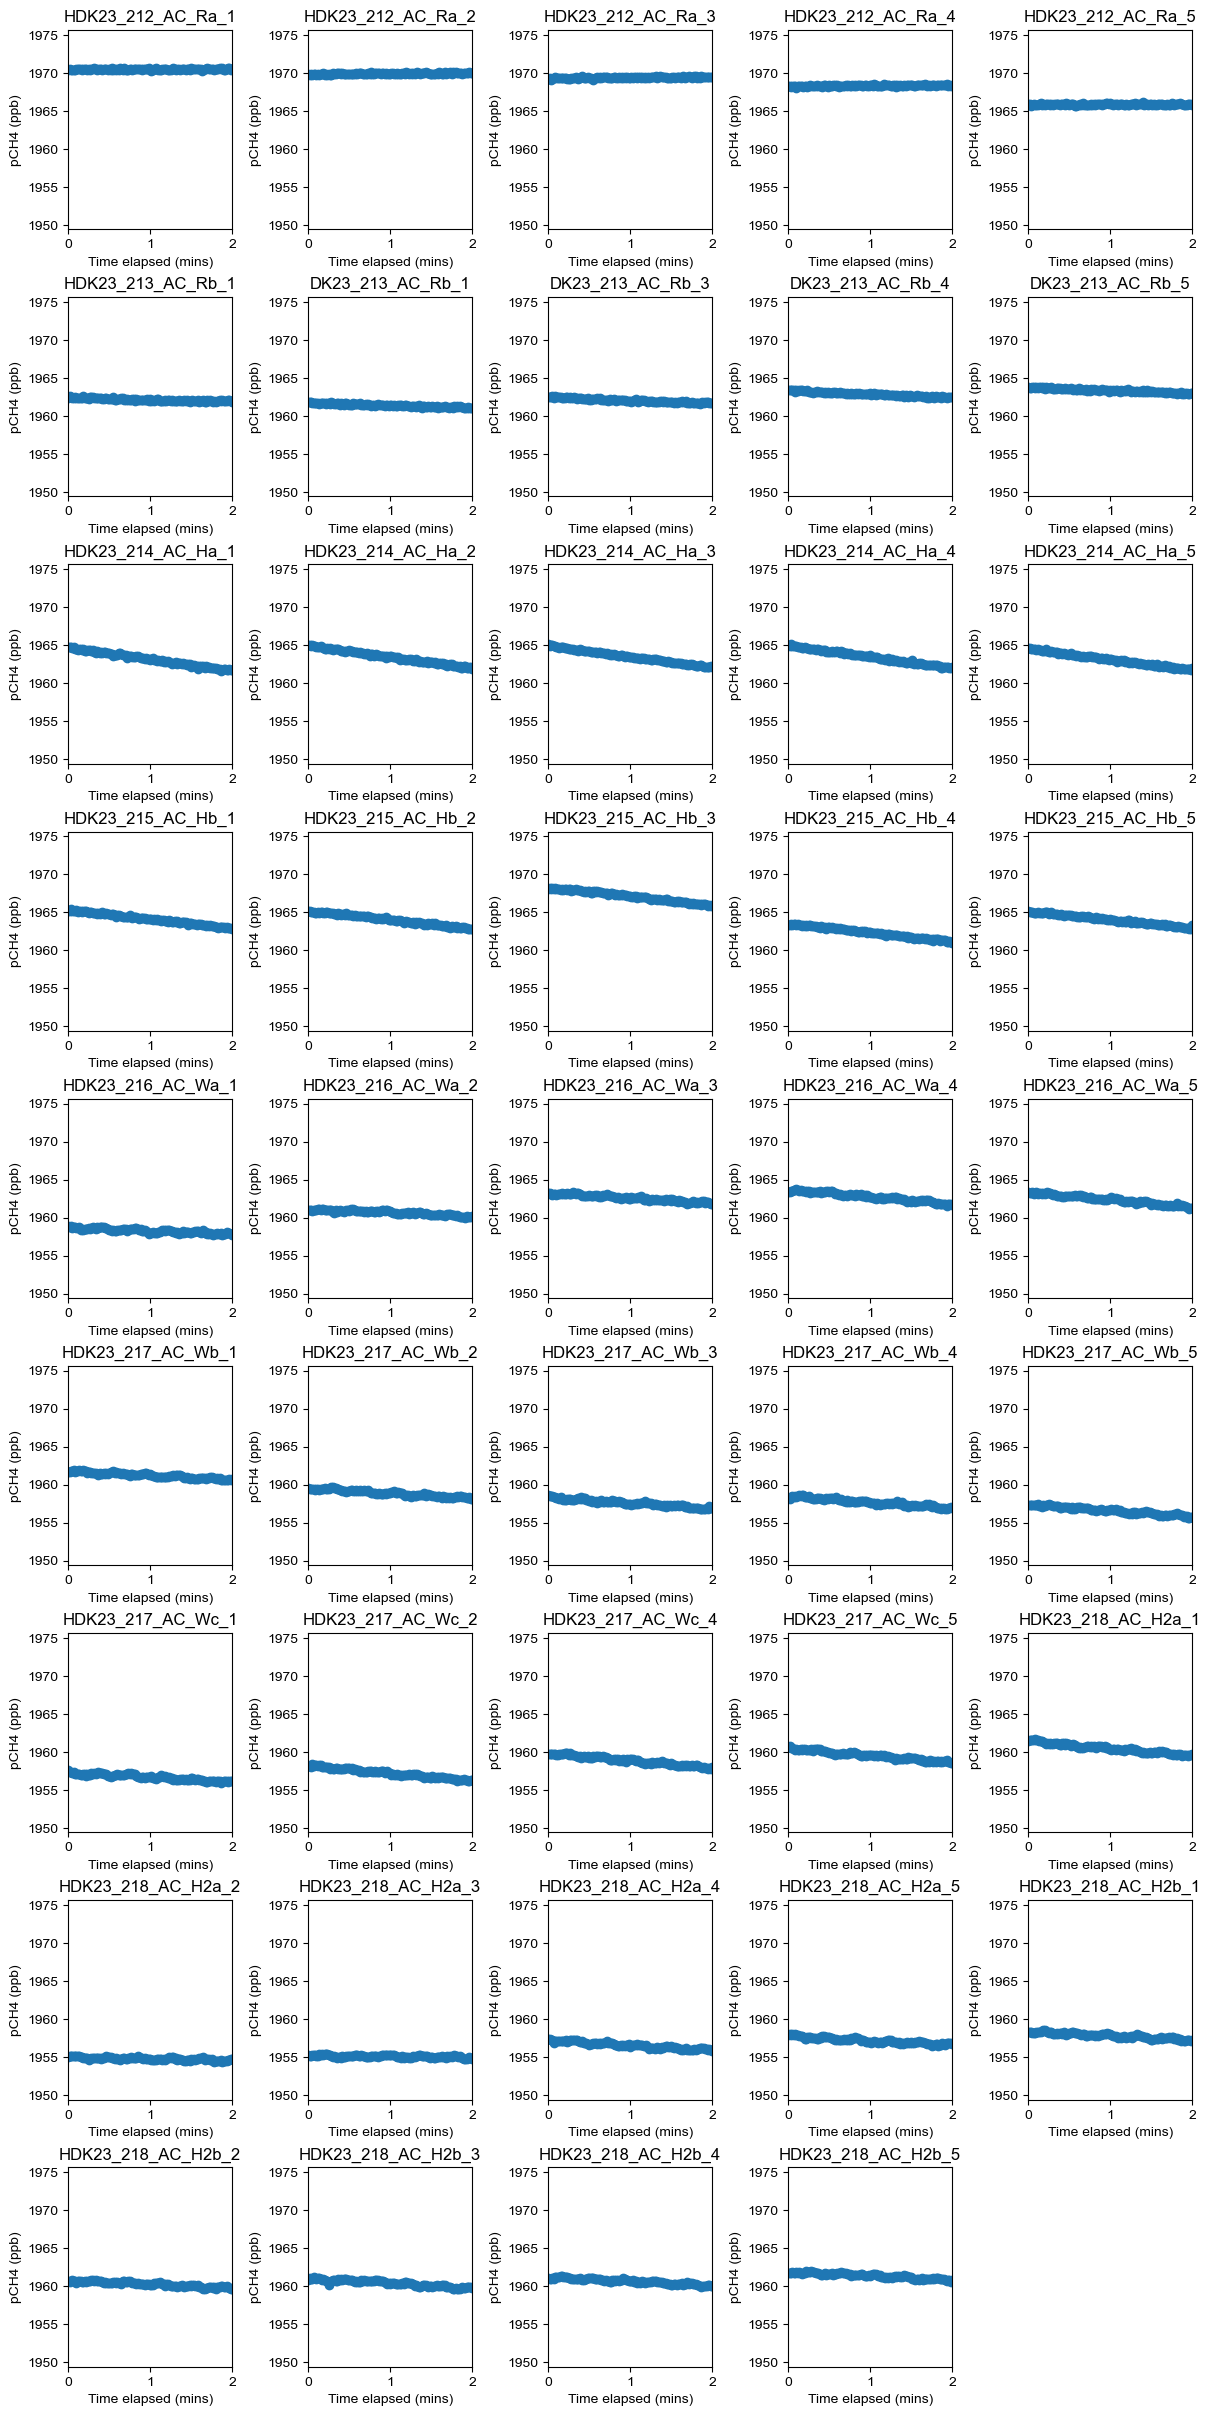

In [33]:
# visualize every flux measurement!

figsize = (12,36)
cols = 5
rows = int(math.ceil(len(flux_dfs)/3))

def trim_axs(axs, N):
    """
    Reduce *axs* to *N* Axes. All further Axes are removed from the figure.
    """
    axs = axs.flat
    for ax in axs[N:]:
        ax.remove()
    return axs[:N]

axs = plt.figure(figsize=figsize, constrained_layout=True).subplots(rows, cols)
axs = trim_axs(axs, len(flux_dfs))

# find values for axis limits
ymin = 3000
ymax = 0
for key in flux_dfs:
    mymin = flux_dfs[key]['CH4_dry'].min()
    if mymin < ymin:
        ymin = mymin
    mymax = flux_dfs[key]['CH4_dry'].max()
    if mymax > ymax:
        ymax = mymax
ymin = ymin - 5
ymax = ymax + 5

for ax, key in zip(axs, flux_dfs):
    ax.set_title(key)
    ax.scatter(flux_dfs[key].Elapsed, flux_dfs[key].CH4_dry)
    ax.set_xlabel('Time elapsed (mins)')
    ax.set_ylabel('pCH4 (ppb)')
    ax.set_ylim(ymin, ymax)
    ax.set_xlim([0,2])

In [34]:
# make a dictionary of the linear regression for each flux

flux_regs = {}

for key in flux_dfs:
    x = flux_dfs[key][['Elapsed']]
    y = flux_dfs[key][['CH4_dry']]
    try:
        model = LinearRegression().fit(x, y)
        flux_regs[key] = [float(model.coef_[0]), float(model.intercept_[0]), model.score(x,y)]
    except:
        print(str(key) + ' does not have enough data to calculate a regression.')
    
x_pred = np.linspace(0,8,50)

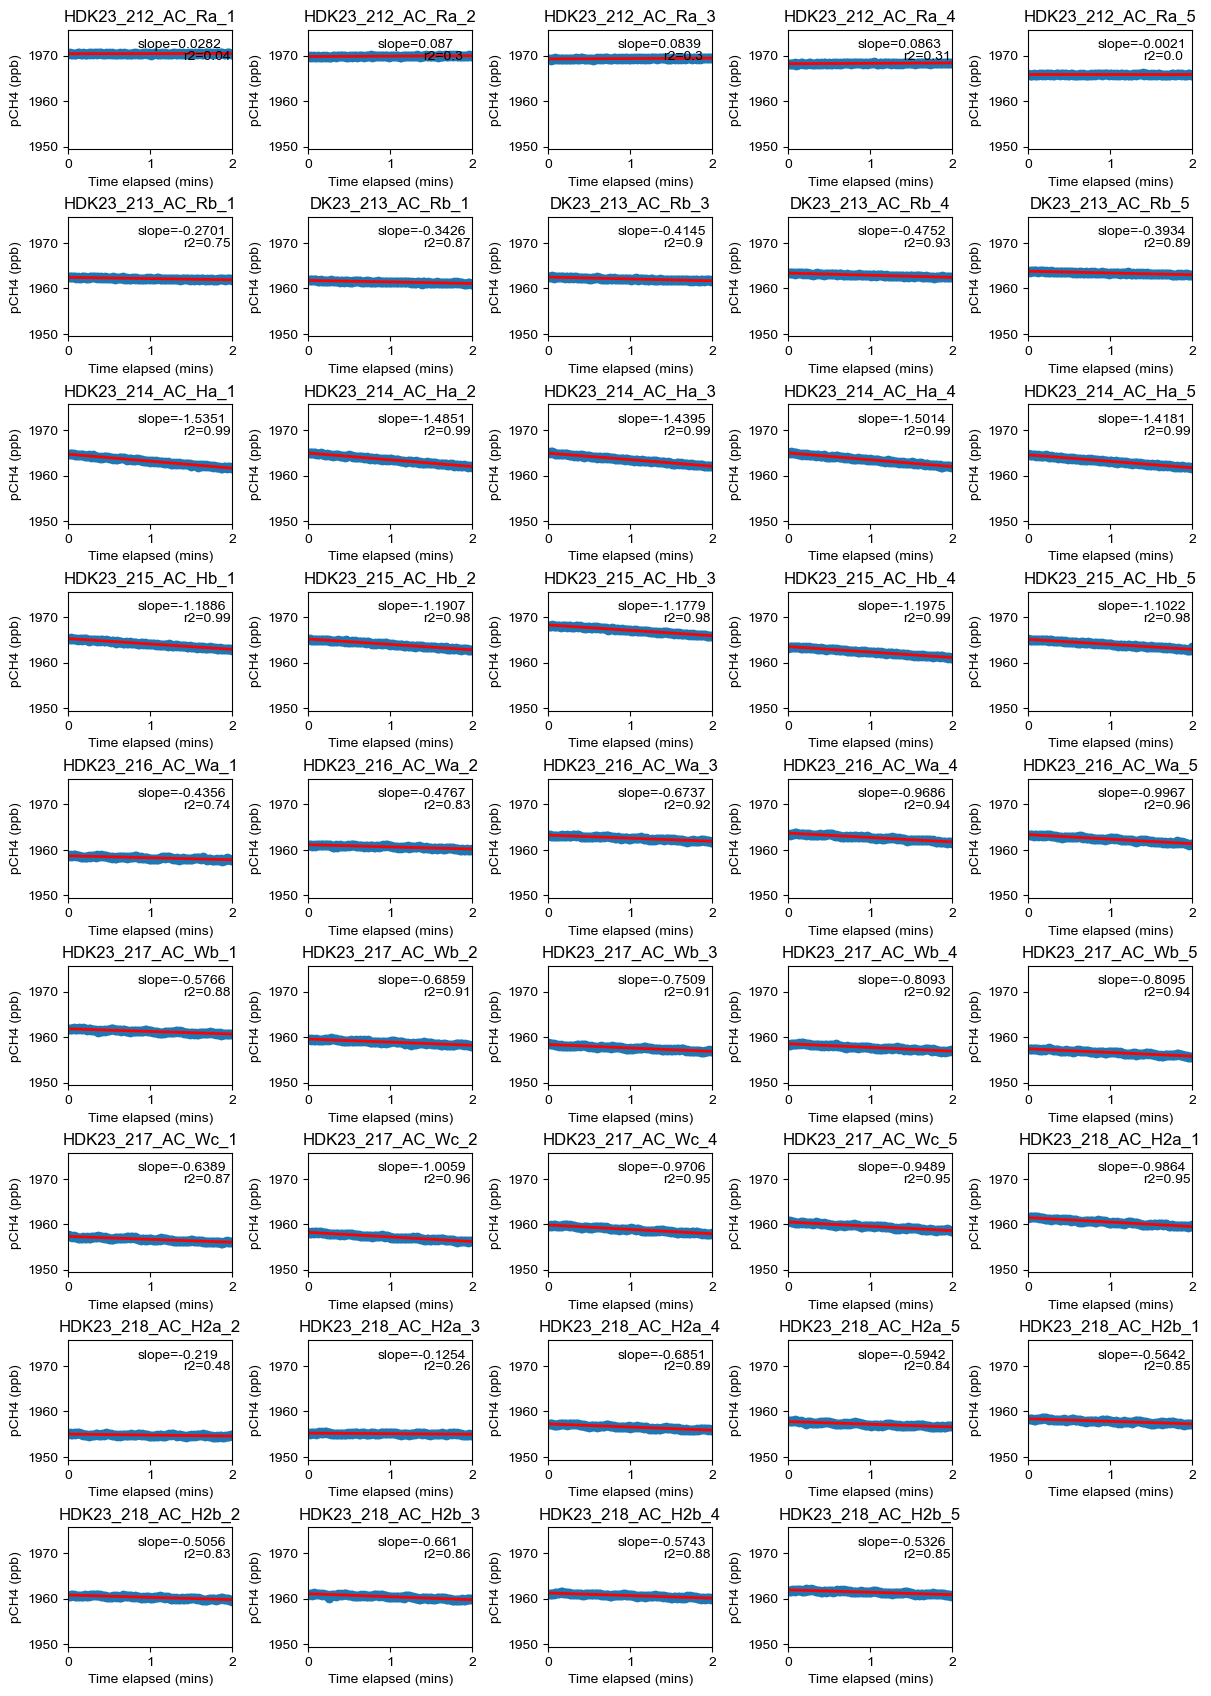

In [35]:
# plot the linear regression, slope, and r2 value for each flux

figsize = (12,24)
cols = 5
rows = int(math.ceil(len(flux_dfs)/3))

text_m = ymax - 0.15*(ymax-ymin)
text_r = ymax - 0.25*(ymax-ymin)

axs = plt.figure(figsize=figsize, constrained_layout = True).subplots(rows, cols)
axs = trim_axs(axs, len(flux_dfs))

for ax, key in zip(axs, flux_dfs):
    ax.set_title(key)
    ax.scatter(flux_dfs[key].Elapsed, flux_dfs[key].CH4_dry)
    ax.set_xlabel('Time elapsed (mins)')
    ax.set_ylabel('pCH4 (ppb)')
    ax.set_ylim([ymin, ymax + 0.02])
    ax.set_xlim([0,2])
    
for ax, key in zip(axs, flux_regs):
    m = flux_regs[key][0]
    b = flux_regs[key][1]
    ax.plot(x_pred, m * x_pred + b, 'r', linewidth=2)
    m = round(m, 4)
    r_sq = flux_regs[key][2]
    r_sq = round(r_sq, 2)
    ax.text(1.4, text_r, ('r2=' + str(r_sq)))
    ax.text(0.85, text_m, ('slope=' + str(m)))
    
plot_name = str(flux_date) + '_raw_flux_regs.png'
plt.savefig(plot_name)

In [36]:
# normalize each dataset against slope in order to identify and remove outliers
# outliers are removed from the normalized data if 
# they are outside of the Q1-Q3 bounds by > 3*IQR

flux_corr = {}

for key in flux_dfs:
    try:
        dat = flux_dfs[key]
        m = flux_regs[key][0]
        b = flux_regs[key][1]
        dat['Pred'] = dat.Elapsed * m + b
        dat['Detrended'] = dat.CH4_dry - dat.Pred
        q3, q1 = np.percentile(dat.Detrended, [75 ,25])
        iqr = q3 - q1
        upperout = q3 + 3*iqr
        lowerout = q1 - 3*iqr
        dat2 = dat[dat.Detrended > lowerout]
        dat2 = dat2[dat2.Detrended < upperout]
        flux_corr[key] = dat2
        rm = len(dat) - len(dat2)
        print(str(rm) + ' rows were removed from ' + str(key) + ' in flux_corr')
    except:
        print(str(key) + ' does not have enough data to remove outliers.')

0 rows were removed from HDK23_212_AC_Ra_1 in flux_corr
0 rows were removed from HDK23_212_AC_Ra_2 in flux_corr
0 rows were removed from HDK23_212_AC_Ra_3 in flux_corr
0 rows were removed from HDK23_212_AC_Ra_4 in flux_corr
0 rows were removed from HDK23_212_AC_Ra_5 in flux_corr
0 rows were removed from HDK23_213_AC_Rb_1 in flux_corr
0 rows were removed from DK23_213_AC_Rb_1 in flux_corr
0 rows were removed from DK23_213_AC_Rb_3 in flux_corr
0 rows were removed from DK23_213_AC_Rb_4 in flux_corr
0 rows were removed from DK23_213_AC_Rb_5 in flux_corr
0 rows were removed from HDK23_214_AC_Ha_1 in flux_corr
0 rows were removed from HDK23_214_AC_Ha_2 in flux_corr
0 rows were removed from HDK23_214_AC_Ha_3 in flux_corr
0 rows were removed from HDK23_214_AC_Ha_4 in flux_corr
0 rows were removed from HDK23_214_AC_Ha_5 in flux_corr
0 rows were removed from HDK23_215_AC_Hb_1 in flux_corr
0 rows were removed from HDK23_215_AC_Hb_2 in flux_corr
0 rows were removed from HDK23_215_AC_Hb_3 in flux_c

In [37]:
# make a dictionary of the linear regression for each cleaned-up flux

flux_regs_corr = {}
flux_regs_conf = {}

for key in flux_corr:
    try:
        x = flux_corr[key][['Elapsed']]
        X = sm.add_constant(x)
        y = flux_corr[key][['CH4_dry']]
        model = sm.OLS(y, X).fit()
        flux_regs_corr[key] = [model.params[1], model.params[0], model.rsquared]
        conf_interval = model.conf_int(alpha=0.05)  # 95% CI
        flux_regs_conf[key] = conf_interval.iloc[1]
    except:
        print(str(key) + ' does not have enough data to calculate a regression.')
        flux_regs_corr[key] = [0, 0, 0]
        flux_regs_conf[key] = [0, 0]

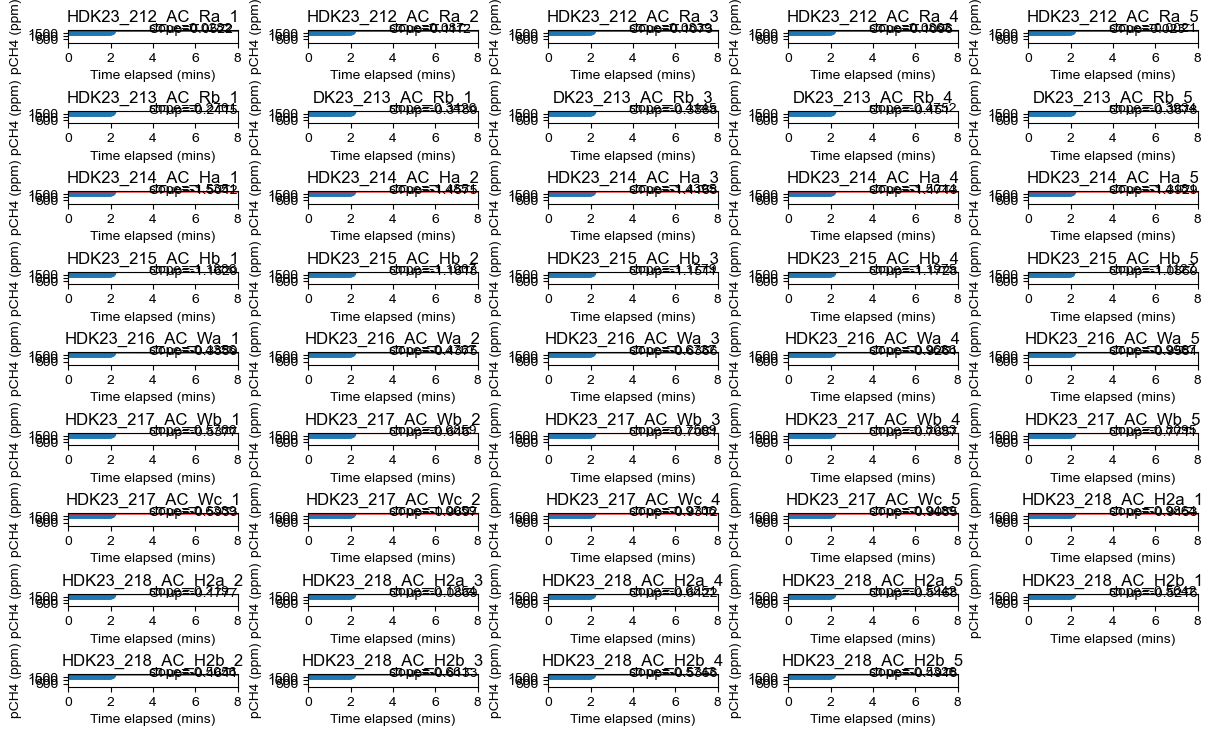

In [38]:
# now plot the regressions for the newly cleaned-up data

figsize = (12,8)
cols = 5
rows = int(math.ceil(len(flux_corr)/3))

axs = plt.figure(figsize=figsize, constrained_layout=True).subplots(rows, cols)
axs = trim_axs(axs, len(flux_corr))

# find values for axis limits
ymin = 3
mymin = 3
ymax = 0
mymax = 0
for key in flux_corr:
    mymin = flux_corr[key]['CH4_dry'].min()
    if mymin < ymin:
        ymin = mymin
    mymax = flux_corr[key]['CH4_dry'].max()
    if mymax > ymax:
        ymax = mymax
ymin = ymin - 0.02
ymax = ymax + 0.02

text_m = (ymax - ymin) * 0.12
text_r = (ymax - ymin) * 0.22
    
x_pred = np.linspace(0,8,50)

for ax, key in zip(axs, flux_corr):
    ax.set_title(key)
    ax.scatter(flux_corr[key].Elapsed, flux_corr[key].CH4_dry)
    ax.set_xlabel('Time elapsed (mins)')
    ax.set_ylabel('pCH4 (ppm)')
    ax.set_ylim([ymin, ymax])
    ax.set_xlim([0,8])
    
for ax, key in zip(axs, flux_regs_corr):
    m = flux_regs_corr[key][0]
    b = flux_regs_corr[key][1]
    ax.plot(x_pred, m * x_pred + b, 'r', linewidth=2)
    m = round(m, 4)
    ci_up = flux_regs_conf[key][1]
    ci_up = round(ci_up, 4)
    ax.text(3.8, ymax - text_r, ('CI up=' + str(ci_up)))
    ax.text(3.8, ymax - text_m, ('slope=' + str(m)))
    
    
plot_name = str(flux_date) + '_cleaned_flux_regs.png'
plt.savefig(plot_name)

plot_name2 = str(flux_date) + '_cleaned_flux_regs.pdf'
plt.savefig(plot_name2)

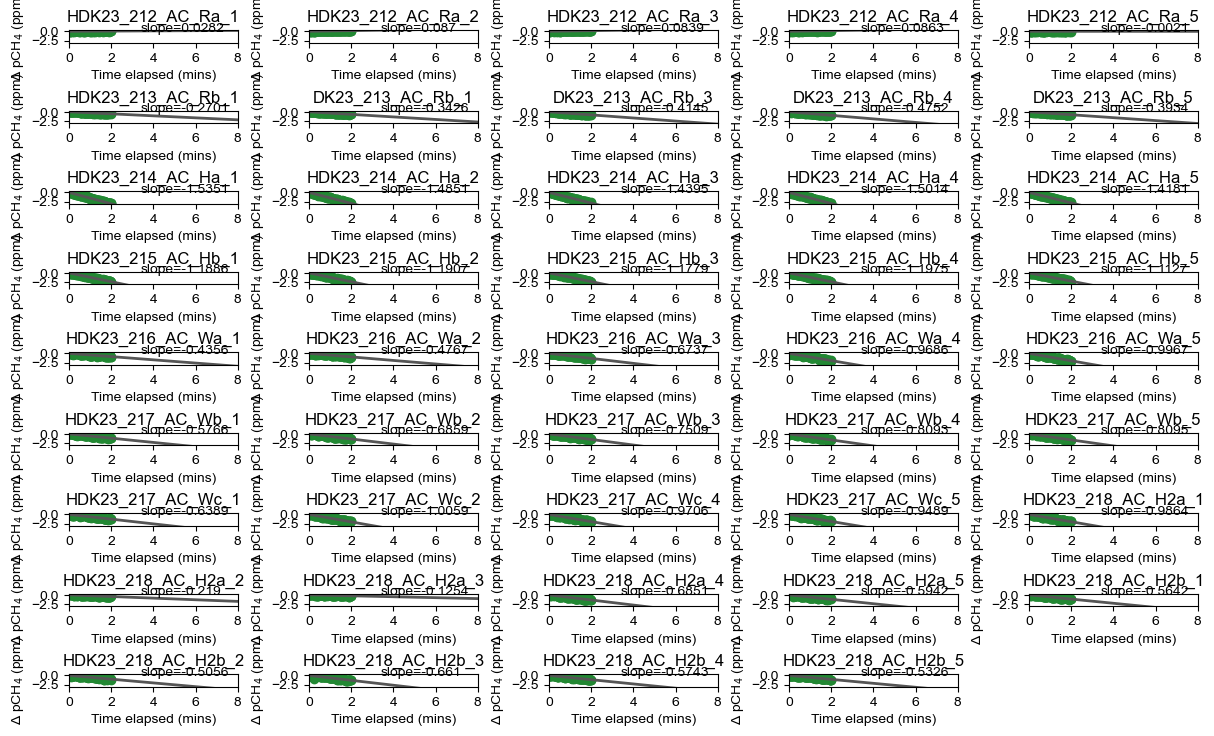

In [39]:
# plot data one other way, so that the scales look nicer

# first, calculate relative change in pCH4

flux_rel = {}
startvals = {}
myvals = []
for key in flux_corr:
    mycol = flux_corr[key]['CH4_dry']
    startval = flux_regs_corr[key][1]
    startvals[key] = startval
    for value in mycol:
        myval = value - startval
        myvals.append(myval)
    flux_rel[key] = pd.DataFrame()
    flux_rel[key]['Change'] = myvals
    myvals = []
    
# now set up your plot

xlab = 'Time elapsed (mins)'
ylab = 'Δ pCH$_4$ (ppm)'

figsize = (12,8)
cols = 5
rows = int(math.ceil(len(flux_corr)/3))

axs = plt.figure(figsize=figsize, constrained_layout=True).subplots(rows, cols)
axs = trim_axs(axs, len(flux_corr))

# find values for axis limits
ymin = 3
mymin = 3
ymax = -3
mymax = -3
for key in flux_rel:
    mymin = flux_rel[key]['Change'].min()
    if mymin < ymin:
        ymin = mymin
    mymax = flux_rel[key]['Change'].max()
    if mymax > ymax:
        ymax = mymax
ymin = ymin - 0.02
ymax = ymax + 0.02

text_m = (ymax - ymin) * 0.12
text_r = (ymax - ymin) * 0.22
    
x_pred = np.linspace(0,8,50)

for ax, key in zip(axs, flux_corr):
    ax.set_title(key)
    ax.scatter(flux_corr[key].Elapsed,
               flux_rel[key].Change,
              color = '#228833')
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_ylim([ymin, ymax])
    ax.set_xlim([0,8])
    
for ax, key in zip(axs, flux_regs_corr):
    m = flux_regs_corr[key][0]
    b = flux_regs_corr[key][1] - startvals[key]
    ax.plot(x_pred, 
            m * x_pred + b, 
            color = '#555555',
            linewidth=2)
    m = round(m, 4)
    ci_up = flux_regs_conf[key][1]
    ci_up = round(ci_up, 4)
   # ax.text(3.4, ymax - text_r, ('CIup=' + str(ci_up)))
    ax.text(3.4, ymax - text_m, ('slope=' + str(m)))
    
    
plot_name = str(flux_date) + '_cleaned_flux_relative.png'
plt.savefig(plot_name)

plot_name2 = str(flux_date) + '_cleaned_flux_relative.pdf'
plt.savefig(plot_name2)

In [40]:
# prepare temperature data for flux calculations
# need to trim flux_info so it only includes data for which a reg could be calculated

my_keys = []
for key in flux_regs_corr:
    my_keys.append(key)
my_flux_info = flux_info[flux_info['flux_name'].isin(my_keys)]

missing = my_flux_info.isna()

temps = []

# assemble a new dictionary with just the slopes, in ppm/min

flux_slopes = {}
for key in flux_corr:
    flux_slopes[key] = flux_regs_corr[key][0]

for i, key in enumerate(flux_slopes):
    if missing.air_temp[i] == False:
        temp = my_flux_info.air_temp[i]
    elif missing.flux_temp[i] == False:
        temp = my_flux_info.flux_temp[i]
    else:
        temp = 23.9 # 75 F in C
    temps.append(temp)

temps


[28,
 28,
 28,
 28,
 28,
 28,
 28,
 28,
 28,
 28,
 32,
 32,
 32,
 32,
 32,
 34,
 34,
 34,
 34,
 34,
 36,
 36,
 36,
 36,
 36,
 35,
 35,
 35,
 35,
 35,
 33,
 33,
 33,
 33,
 33,
 34,
 34,
 34,
 34,
 34,
 38,
 38,
 38,
 38]

In [52]:
# prepare volume data for calculations

vols = flux_info.volume.tolist()
myvols = []
for item in vols:
    vol = item/1000
    myvols.append(vol)

In [53]:
# calculate the actual flux from slope!
# also, calculate error in flux based on confidence interval
# output: flux in μg methane per square meter per hour

min_hr = 60
volume = 8.2 # L # you will want to double check this value!
area = 0.0312 # m^2
pressure = 101325 # Pa
R = 8314.46261815324 # Pa L K^-1 mol^-1
ch4_mm = 16.04 # g mol^-1

flux_true = {}

for i, key in enumerate(flux_slopes):
    flux_true[key] = (flux_slopes[key]/1000
                      * pressure
                      * myvols[i] # you can just set this volume if chamber volume is the same for every measurement
                      * min_hr
                      / area
                      / R
                      / (temps[i] + 273.15)
                      * ch4_mm
                     )
    

flux_error = {}

for i, key in enumerate(flux_regs_conf):
    a = flux_regs_conf[key]
    err_slopes = []
    for slope in a:
        err_slope = (slope/1000
                     * pressure
                     * myvols[i]
                     * min_hr
                     / area
                     / R
                     / (temps[i] + 273.15)
                     * ch4_mm
                    )
        err_slopes.append(err_slope)
    flux_error[key] = err_slopes

[flux_true, flux_error]

[{'HDK23_212_AC_Ra_1': 0.23870447023426766,
  'HDK23_212_AC_Ra_2': 0.7370081928904868,
  'HDK23_212_AC_Ra_3': 0.710692172786852,
  'HDK23_212_AC_Ra_4': 0.7312524555211911,
  'HDK23_212_AC_Ra_5': -0.017987960464031144,
  'HDK23_213_AC_Rb_1': -2.2615653835410545,
  'DK23_213_AC_Rb_1': -2.869133093325971,
  'DK23_213_AC_Rb_3': -3.4707667099653956,
  'DK23_213_AC_Rb_4': -3.9790349924938027,
  'DK23_213_AC_Rb_5': -3.2940163479585722,
  'HDK23_214_AC_Ha_1': -13.498579874894089,
  'HDK23_214_AC_Ha_2': -13.058674183609238,
  'HDK23_214_AC_Ha_3': -12.657942751105828,
  'HDK23_214_AC_Ha_4': -13.201735245056126,
  'HDK23_214_AC_Ha_5': -12.469104276589123,
  'HDK23_215_AC_Hb_1': -9.874936623688148,
  'HDK23_215_AC_Hb_2': -9.892203122639794,
  'HDK23_215_AC_Hb_3': -9.785886663710526,
  'HDK23_215_AC_Hb_4': -9.948731327163063,
  'HDK23_215_AC_Hb_5': -9.243977452998974,
  'HDK23_216_AC_Wa_1': -3.8311723283526726,
  'HDK23_216_AC_Wa_2': -4.192373400755426,
  'HDK23_216_AC_Wa_3': -5.925224379732917,
  

In [54]:
plus_minus = {}

for key in flux_error:
    err_slopes = flux_error[key]
    pm = abs(err_slopes[1] - err_slopes[0])/2
    plus_minus[key] = pm

sig_flux = {} # this makes a new dictionary where any fluxes not significantly different from 0 are set to 0

for key in flux_true:
    a = abs(flux_true[key])
    b = plus_minus[key]
    if b > a:
        sig_flux[key] = 0
        print('Flux for ' + str(key) + ' is not significantly different from 0.')
    else:
        sig_flux[key] = flux_true[key]

Flux for HDK23_212_AC_Ra_5 is not significantly different from 0.


In [55]:
# put everything into a dataframe

flux_true_forcsv = pd.DataFrame.from_dict(flux_true, orient = 'index', columns = ['flux-ch4'])
plus_minus_forcsv = pd.DataFrame.from_dict(plus_minus, orient = 'index', columns = ['95-ci'])
sig_flux_forcsv = pd.DataFrame.from_dict(sig_flux, orient = 'index', columns = ['flux-ch4-sig'])
flux_true_forcsv = flux_true_forcsv.merge(plus_minus_forcsv, left_index = True, right_index = True)
flux_true_forcsv = flux_true_forcsv.merge(sig_flux_forcsv, left_index = True, right_index = True)

In [56]:
# finally, output to a csv!

flux_true_forcsv.to_csv(str(flux_date + '_fluxes_ug-per-hr.csv'))